<a href="https://colab.research.google.com/github/Shraddha6211/Machine-Learning-Extra-Class/blob/main/ANN_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
from google.colab import files
files.upload()


Saving car_purchasing.csv to car_purchasing (2).csv


{'car_purchasing (2).csv': b'customer name,JobTitle,customer e-mail,country,gender,age,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,credit card debt,net worth,car purchase amount\r\nMartina Avila,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,42,167411.18,0,400184.25,,567595.43,567595.43,11609.38091,238961.2505,35321.45877\r\nHarlan Barnes,CAPTAIN III (POLICE DEPARTMENT),eu.dolor@diam.co.uk,Belize,0,41,155966.02,245131.88,137811.38,,538909.28,538909.28,9572.957136,530973.9078,45115.52566\r\nNaomi Rodriquez,CAPTAIN III (POLICE DEPARTMENT),vulputate.mauris.sagittis@ametconsectetueradipiscing.co.uk,Algeria,1,43,212739.13,106088.18,16452.6,,335279.91,335279.91,11160.35506,638467.1773,42925.70921\r\nJade Cunningham,WIRE ROPE CABLE MAINTENANCE MECHANIC,malesuada@dignissim.com,Cook Islands,1,58,77916,56120.71,198306.9,,332343.61,332343.61,14426.16485,548599.0524,67422.36313\r\nCedric Leach,"DEPUTY CHIEF OF DEPARTM

In [40]:
import pandas as pd

df= pd.read_csv('car_purchasing.csv', encoding='latin1')
df.head(3)

,customer name,JobTitle,customer e-mail,country,gender,age,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,credit card debt,net worth,car purchase amount
0,Martina Avila,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,42,167411.18,0.00,400184.25,NaN,567595.43,567595.43,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,CAPTAIN III (POLICE DEPARTMENT),eu.dolor@diam.co.uk,Belize,0,41,155966.02,245131.88,137811.38,NaN,538909.28,538909.28,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,CAPTAIN III (POLICE DEPARTMENT),vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43,212739.13,106088.18,16452.60,NaN,335279.91,335279.91,11160.355060,638467.1773,42925.70921


In [41]:
df= df.drop([
    'customer name',
    'customer e-mail',
    'country',
    'Benefits',
    'JobTitle'

], axis =1)
df.sample(3)

,gender,age,BasePay,OvertimePay,OtherPay,TotalPay,TotalPayBenefits,credit card debt,net worth,car purchase amount
270,0,35,105934.66,75817.75,17540.56,199292.97,199292.97,8570.611562,211168.6293,12536.93842
279,0,48,105934.66,70730.50,21611.32,198276.48,198276.48,8774.069514,210573.7042,41034.28343
384,0,44,122404.99,54524.26,15277.88,192207.13,192207.13,6139.387823,674190.6949,57303.87131


In [42]:
X = df.drop('car purchase amount', axis =1)
y = df['car purchase amount']
X.head(3)

,gender,age,BasePay,OvertimePay,OtherPay,TotalPay,TotalPayBenefits,credit card debt,net worth
0,0,42,167411.18,0.00,400184.25,567595.43,567595.43,11609.380910,238961.2505
1,0,41,155966.02,245131.88,137811.38,538909.28,538909.28,9572.957136,530973.9078
2,1,43,212739.13,106088.18,16452.60,335279.91,335279.91,11160.355060,638467.1773


In [43]:
# Create 3 classes using quantiles
y_class =pd.qcut(
    y,
    q=3,
    labels=[0,1,2]
)

# Convert category to int
y_class = y_class.astype(int)

In [44]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix



In [45]:
y_cat = to_categorical(y_class, num_classes=3)
y_cat

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       ...,
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.]])

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)

In [47]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [48]:
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')       # 3 categorical outputs
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

In [50]:
history = model.fit(
    X_train,
    y_train,
    epochs = 10,
    batch_size = 32,
    validation_split = 0.2,
    verbose =1
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4250 - loss: 1.0671 - val_accuracy: 0.5250 - val_loss: 1.0040
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5813 - loss: 0.9489 - val_accuracy: 0.5250 - val_loss: 0.9347
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6250 - loss: 0.8602 - val_accuracy: 0.6000 - val_loss: 0.8865
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6625 - loss: 0.7989 - val_accuracy: 0.6000 - val_loss: 0.8625
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6781 - loss: 0.7589 - val_accuracy: 0.5375 - val_loss: 0.8559
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6938 - loss: 0.7297 - val_accuracy: 0.5500 - val_loss: 0.8556
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7031 - loss: 0.7089 - val_accuracy: 0.5500 - val_loss: 0.8581
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6875 - loss: 0.6947 - val_accuracy: 0.5375 - val_loss

In [51]:
y_pred = np.argmax(model.predict(X_test), axis=-1)
y_true = np.argmax(y_test, axis=-1)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
[[23  5  0]
 [ 7 17 11]
 [ 2  8 27]]
              precision    recall  f1-score   support

           0       0.72      0.82      0.77        28
           1       0.57      0.49      0.52        35
           2       0.71      0.73      0.72        37

    accuracy                           0.67       100
   macro avg       0.67      0.68      0.67       100
weighted avg       0.66      0.67      0.66       100



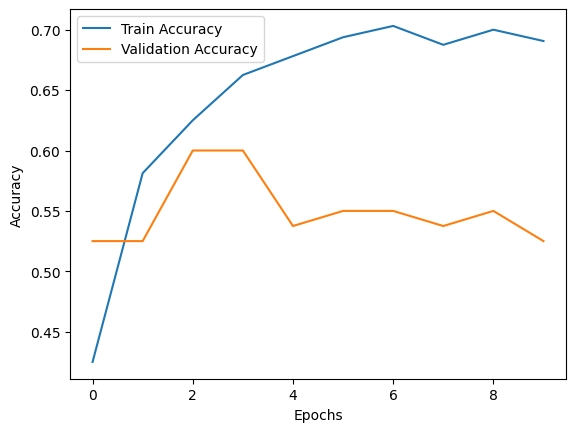

In [52]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [54]:
# Same feature order as training
new_customer = np.array([[
    1,45,50000,2000,1500,3000,56500,59500,120000

]])

# Scale
new_customer_scaled = scaler.transform(new_customer)

# Predict probabilities
probs = model.predict(new_customer_scaled)

# Predicted class
predicted_class = np.argmax(probs, axis=1)[0]
print("Class probabilities:", probs[0])
print("Predicted class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Class probabilities: [0.03695323 0.9326934  0.03035339]
Predicted class: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [55]:
labels = {0:"Low Potential Buyer", 1:"Medium Potential Buyer", 2:"High Potential Buyer"}
print("Predicted Category:",labels[predicted_class])

Predicted Category: Medium Potential Buyer
